In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)
from sklearn.model_selection import StratifiedKFold
import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances
)
import joblib
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("All imports done")

c:\Users\shravan kumar\OneDrive\Desktop\github\credit-card-fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports done


In [2]:
X_train = joblib.load('../data/X_train.pkl')
y_train = joblib.load('../data/y_train.pkl')
X_test  = joblib.load('../data/X_test.pkl')
y_test  = joblib.load('../data/y_test.pkl')

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos

print("=== DATA LOADED ===")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Scale pos weight: {scale_pos:.1f}")

=== DATA LOADED ===
X_train : (227845, 35)
X_test  : (56962, 35)
Scale pos weight: 577.3


In [5]:
def xgb_objective(trial):
    params = {
        'n_estimators'        : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'           : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'       : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample'           : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'    : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'           : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'          : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_weight'    : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'               : trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight'    : scale_pos,
        'eval_metric'         : 'aucpr',
        'early_stopping_rounds': 30,      # ← moved here into constructor
        'random_state'        : 42,
        'verbosity'           : 0
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pr_auc_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr  = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False              # ← early_stopping_rounds removed from here
        )

        prob = model.predict_proba(X_val)[:, 1]
        pr_auc_scores.append(average_precision_score(y_val, prob))

    return np.mean(pr_auc_scores)

print("XGBoost objective defined")

XGBoost objective defined


In [6]:
# This takes 20-40 minutes depending on your machine
# Set n_trials=50 for a quick run, 100 for best results

print("Running Optuna for XGBoost...")
print("100 trials × 5-fold CV = 500 model fits")
print("Estimated time: 20-40 minutes\n")

xgb_study = optuna.create_study(
    direction='maximize',
    study_name='xgb_fraud_detection',
    sampler=optuna.samplers.TPESampler(seed=42)
)

xgb_study.optimize(
    xgb_objective,
    n_trials=100,
    show_progress_bar=True
)

print(f"\n=== XGB OPTUNA COMPLETE ===")
print(f"Best PR-AUC (CV) : {xgb_study.best_value:.4f}")
print(f"Best params:")
for k, v in xgb_study.best_params.items():
    print(f"  {k:<22}: {v}")

Running Optuna for XGBoost...
100 trials × 5-fold CV = 500 model fits
Estimated time: 20-40 minutes



Best trial: 64. Best value: 0.85166: 100%|██████████| 100/100 [26:06<00:00, 15.67s/it]


=== XGB OPTUNA COMPLETE ===
Best PR-AUC (CV) : 0.8517
Best params:
  n_estimators          : 515
  max_depth             : 7
  learning_rate         : 0.13738322667823327
  subsample             : 0.8060403523531873
  colsample_bytree      : 0.9463300911139547
  reg_alpha             : 0.010536255276418674
  reg_lambda            : 0.11210660231927695
  min_child_weight      : 10
  gamma                 : 1.9822450901532571


In [7]:
def lgbm_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight' : scale_pos,
        'random_state'     : 42,
        'verbose'          : -1
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pr_auc_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr  = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                __import__('lightgbm').early_stopping(30, verbose=False),
                __import__('lightgbm').log_evaluation(period=-1)
            ]
        )

        prob = model.predict_proba(X_val)[:, 1]
        pr_auc_scores.append(average_precision_score(y_val, prob))

    return np.mean(pr_auc_scores)

print("LightGBM objective defined")

LightGBM objective defined


In [8]:
print("Running Optuna for LightGBM...")
print("100 trials × 5-fold CV = 500 model fits")
print("Estimated time: 20-40 minutes\n")

lgbm_study = optuna.create_study(
    direction='maximize',
    study_name='lgbm_fraud_detection',
    sampler=optuna.samplers.TPESampler(seed=42)
)

lgbm_study.optimize(
    lgbm_objective,
    n_trials=100,
    show_progress_bar=True
)

print(f"\n=== LGBM OPTUNA COMPLETE ===")
print(f"Best PR-AUC (CV) : {lgbm_study.best_value:.4f}")
print(f"Best params:")
for k, v in lgbm_study.best_params.items():
    print(f"  {k:<22}: {v}")

Running Optuna for LightGBM...
100 trials × 5-fold CV = 500 model fits
Estimated time: 20-40 minutes



Best trial: 78. Best value: 0.846335: 100%|██████████| 100/100 [37:18<00:00, 22.38s/it]


=== LGBM OPTUNA COMPLETE ===
Best PR-AUC (CV) : 0.8463
Best params:
  n_estimators          : 884
  learning_rate         : 0.016645315820186052
  num_leaves            : 32
  max_depth             : 6
  min_child_samples     : 22
  subsample             : 0.5925152225470545
  colsample_bytree      : 0.5957809039860866
  reg_alpha             : 0.003700165001142399
  reg_lambda            : 1.6711493290245354


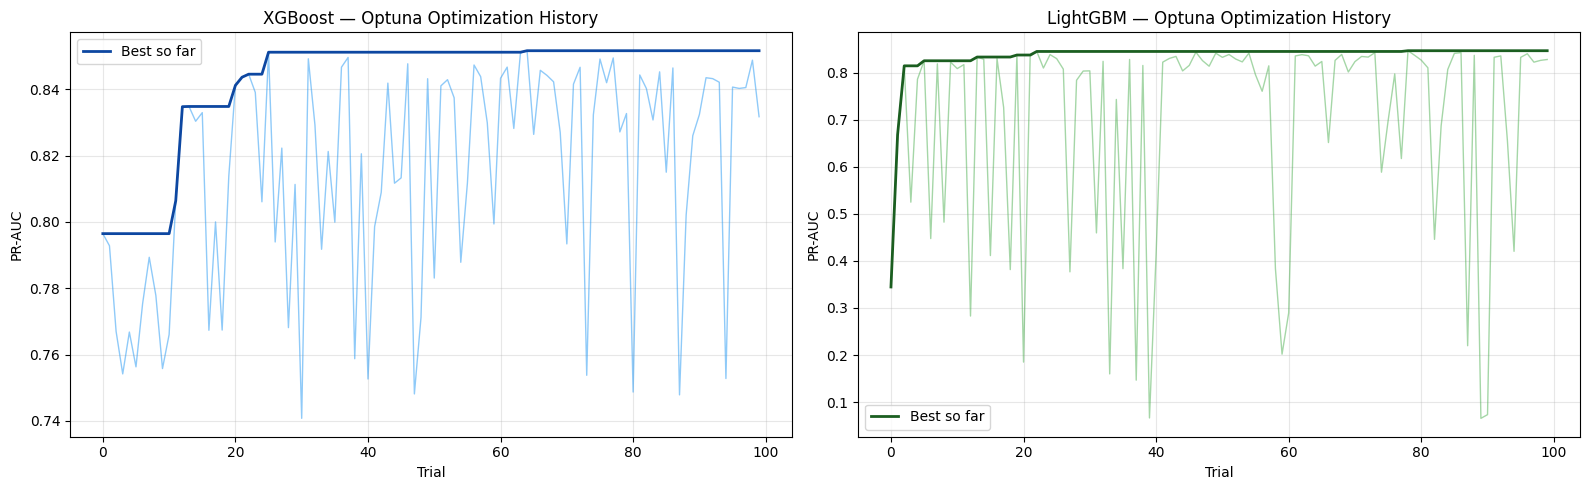

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# XGBoost history
xgb_values = [t.value for t in xgb_study.trials if t.value is not None]
axes[0].plot(xgb_values, color='#2196F3', linewidth=1, alpha=0.5)
axes[0].plot(pd.Series(xgb_values).cummax(),
             color='#0D47A1', linewidth=2, label='Best so far')
axes[0].set_title('XGBoost — Optuna Optimization History')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('PR-AUC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LightGBM history
lgbm_values = [t.value for t in lgbm_study.trials if t.value is not None]
axes[1].plot(lgbm_values, color='#4CAF50', linewidth=1, alpha=0.5)
axes[1].plot(pd.Series(lgbm_values).cummax(),
             color='#1B5E20', linewidth=2, label='Best so far')
axes[1].set_title('LightGBM — Optuna Optimization History')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('PR-AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/15_optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("Retraining final XGBoost on full training data...")

best_xgb_params = xgb_study.best_params.copy()
best_xgb_params.update({
    'scale_pos_weight'     : scale_pos,
    'eval_metric'          : 'aucpr',
    'early_stopping_rounds': 30,       # ← here too
    'random_state'         : 42,
    'verbosity'            : 0
})

final_xgb = XGBClassifier(**best_xgb_params)
final_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False                      # ← removed from here
)

y_prob_final_xgb = final_xgb.predict_proba(X_test)[:, 1]
roc_final_xgb    = roc_auc_score(y_test, y_prob_final_xgb)
prauc_final_xgb  = average_precision_score(y_test, y_prob_final_xgb)

print(f"Final XGBoost ROC-AUC : {roc_final_xgb:.4f}")
print(f"Final XGBoost PR-AUC  : {prauc_final_xgb:.4f}")

Retraining final XGBoost on full training data...
Final XGBoost ROC-AUC : 0.9805
Final XGBoost PR-AUC  : 0.8722


In [12]:
print("Retraining final LightGBM on full training data...")

best_lgbm_params = lgbm_study.best_params.copy()
best_lgbm_params.update({
    'scale_pos_weight' : scale_pos,
    'random_state'     : 42,
    'verbose'          : -1
})

final_lgbm = LGBMClassifier(**best_lgbm_params)
final_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        __import__('lightgbm').early_stopping(30, verbose=False),
        __import__('lightgbm').log_evaluation(period=-1)
    ]
)

y_prob_final_lgbm = final_lgbm.predict_proba(X_test)[:, 1]
roc_final_lgbm    = roc_auc_score(y_test, y_prob_final_lgbm)
prauc_final_lgbm  = average_precision_score(y_test, y_prob_final_lgbm)

print(f"Final LightGBM ROC-AUC : {roc_final_lgbm:.4f}")
print(f"Final LightGBM PR-AUC  : {prauc_final_lgbm:.4f}")

Retraining final LightGBM on full training data...
Final LightGBM ROC-AUC : 0.9748
Final LightGBM PR-AUC  : 0.8718


In [13]:
def optimize_threshold(y_test, y_prob, target_recall=0.85):
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    valid_idx = np.where(recall[:-1] >= target_recall)[0]
    if len(valid_idx) > 0:
        best_idx   = valid_idx[np.argmax(precision[:-1][valid_idx])]
        best_thresh = thresholds[best_idx]
        best_prec   = precision[best_idx]
        best_rec    = recall[best_idx]
    else:
        best_thresh = 0.5
        best_prec   = 0.0
        best_rec    = 0.0
    return best_thresh, best_prec, best_rec

thresh_xgb,  prec_xgb,  rec_xgb  = optimize_threshold(y_test, y_prob_final_xgb)
thresh_lgbm, prec_lgbm, rec_lgbm = optimize_threshold(y_test, y_prob_final_lgbm)

print("=== OPTIMIZED THRESHOLDS ===")
print(f"\nXGBoost  threshold: {thresh_xgb:.4f}")
print(f"  Precision : {prec_xgb:.4f}")
print(f"  Recall    : {rec_xgb:.4f}")

print(f"\nLightGBM threshold: {thresh_lgbm:.4f}")
print(f"  Precision : {prec_lgbm:.4f}")
print(f"  Recall    : {rec_lgbm:.4f}")

y_pred_final_xgb  = (y_prob_final_xgb  >= thresh_xgb).astype(int)
y_pred_final_lgbm = (y_prob_final_lgbm >= thresh_lgbm).astype(int)

print("\n=== FINAL XGB REPORT ===")
print(classification_report(y_test, y_pred_final_xgb,
      target_names=['Legitimate', 'Fraud']))

print("=== FINAL LGBM REPORT ===")
print(classification_report(y_test, y_pred_final_lgbm,
      target_names=['Legitimate', 'Fraud']))

=== OPTIMIZED THRESHOLDS ===

XGBoost  threshold: 0.5706
  Precision : 0.8571
  Recall    : 0.8571

LightGBM threshold: 0.4382
  Precision : 0.8235
  Recall    : 0.8571

=== FINAL XGB REPORT ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.86      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962

=== FINAL LGBM REPORT ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.86      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [14]:
print("=" * 55)
print("         FINAL MODEL SELECTION")
print("=" * 55)
print(f"\n{'Model':<20} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("-" * 42)
print(f"{'XGBoost (tuned)':<20} {roc_final_xgb:>10.4f} {prauc_final_xgb:>10.4f}")
print(f"{'LightGBM (tuned)':<20} {roc_final_lgbm:>10.4f} {prauc_final_lgbm:>10.4f}")

if prauc_final_xgb >= prauc_final_lgbm:
    best_model       = final_xgb
    best_prob        = y_prob_final_xgb
    best_pred        = y_pred_final_xgb
    best_thresh      = thresh_xgb
    best_model_name  = 'XGBoost'
else:
    best_model       = final_lgbm
    best_prob        = y_prob_final_lgbm
    best_pred        = y_pred_final_lgbm
    best_thresh      = thresh_lgbm
    best_model_name  = 'LightGBM'

print(f"\nWinner: {best_model_name}")
print("=" * 55)

         FINAL MODEL SELECTION

Model                   ROC-AUC     PR-AUC
------------------------------------------
XGBoost (tuned)          0.9805     0.8722
LightGBM (tuned)         0.9748     0.8718

Winner: XGBoost


In [15]:
joblib.dump(final_xgb,         '../models/final_xgb.pkl')
joblib.dump(final_lgbm,        '../models/final_lgbm.pkl')
joblib.dump(best_model,        '../models/best_model.pkl')
joblib.dump(best_thresh,       '../models/best_threshold.pkl')
joblib.dump(y_prob_final_xgb,  '../data/y_prob_final_xgb.pkl')
joblib.dump(y_prob_final_lgbm, '../data/y_prob_final_lgbm.pkl')
joblib.dump(best_prob,         '../data/y_prob_best.pkl')
joblib.dump(best_pred,         '../data/y_pred_best.pkl')

final_results = {
    'model'          : best_model_name,
    'roc_auc'        : round(roc_final_xgb if best_model_name=='XGBoost'
                             else roc_final_lgbm, 4),
    'pr_auc'         : round(prauc_final_xgb if best_model_name=='XGBoost'
                             else prauc_final_lgbm, 4),
    'threshold'      : round(best_thresh, 4),
    'xgb_roc'        : round(roc_final_xgb, 4),
    'xgb_prauc'      : round(prauc_final_xgb, 4),
    'lgbm_roc'       : round(roc_final_lgbm, 4),
    'lgbm_prauc'     : round(prauc_final_lgbm, 4),
}

joblib.dump(final_results, '../models/final_results.pkl')

print("=== ALL FILES SAVED ===")
print("models/final_xgb.pkl")
print("models/final_lgbm.pkl")
print("models/best_model.pkl       ← goes into Streamlit app")
print("models/best_threshold.pkl   ← goes into Streamlit app")
print("data/y_prob_best.pkl")
print("data/y_pred_best.pkl")

=== ALL FILES SAVED ===
models/final_xgb.pkl
models/final_lgbm.pkl
models/best_model.pkl       ← goes into Streamlit app
models/best_threshold.pkl   ← goes into Streamlit app
data/y_prob_best.pkl
data/y_pred_best.pkl


In [16]:
print("=" * 55)
print("       OPTUNA TUNING COMPLETE")
print("=" * 55)
print(f"""
WHAT HAPPENED
  Ran 100 trials for XGBoost
  Ran 100 trials for LightGBM
  Each trial = 5-fold CV optimizing PR-AUC
  Total model fits: 1000

BEST MODEL
  {best_model_name}
  ROC-AUC   : {final_results['roc_auc']}
  PR-AUC    : {final_results['pr_auc']}
  Threshold : {final_results['threshold']}

IMPROVEMENT OVER BASELINE
  PR-AUC was    : {joblib.load('../models/baseline_results.pkl')['pr_auc']}
  PR-AUC now    : {final_results['pr_auc']}
  Gain          : +{final_results['pr_auc'] - joblib.load('../models/baseline_results.pkl')['pr_auc']:.4f}

NEXT STEP
  → Open 06_evaluation.ipynb
  → Final charts, ensemble, business impact numbers
""")
print("=" * 55)

       OPTUNA TUNING COMPLETE

WHAT HAPPENED
  Ran 100 trials for XGBoost
  Ran 100 trials for LightGBM
  Each trial = 5-fold CV optimizing PR-AUC
  Total model fits: 1000

BEST MODEL
  XGBoost
  ROC-AUC   : 0.9805
  PR-AUC    : 0.8722
  Threshold : 0.5705999732017517

IMPROVEMENT OVER BASELINE
  PR-AUC was    : 0.7316
  PR-AUC now    : 0.8722
  Gain          : +0.1406

NEXT STEP
  → Open 06_evaluation.ipynb
  → Final charts, ensemble, business impact numbers

